这里说频率是指一个机场航班出现的频率

## 加载数据

数据已经预处理过了

In [1]:
import pandas as pd


# 加载数据
pd.set_option('display.max_columns', None)  # 显示所有列

data = pd.read_csv('../../my/hh_result/result_24_7-10-pax>20.csv', dtype={'aircraft': str})

# 查看前几行数据，确保加载成功
print(data.head())

print(data.info())

  flt_no    a    b    c bd_type    cap aircraft  legs  leg_no  duration  pax  \
0   3004  NKG  DYG  NaN      窄体  132.0      319     1       1      1.50  120   
1   3126  KMG  ZHY  PEK      窄体  164.0      320     3       2      1.48   72   
2   3126  KMG  ZHY  PEK      窄体  164.0      320     3       1      1.95   28   
3   3153  HGH  CAN  NaN      窄体  189.0      321     1       1      1.60  177   
4   3154  CAN  HGH  NaN      窄体  189.0      321     1       1      1.67  132   

   year  month  day  weekday  hour  minute  second from   to   unit_price  
0  2024      7    3        2    20      10       0  NKG  DYG   544.083333  
1  2024      7    3        2    15      55       0  ZHY  PEK  1060.694444  
2  2024      7    3        2    13       0       0  KMG  ZHY   475.000000  
3  2024      7    3        2     7       5       0  HGH  CAN   476.214689  
4  2024      7    3        2    10      40       0  CAN  HGH   560.075758  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465649 entri

In [2]:
# 随机抽取5万条数据
data = data.sample(n=50000, random_state=42)

# 保存原始数据的副本
data_origin = data.copy()

# 查看抽样后的数据信息
print(data.info())

<class 'pandas.core.frame.DataFrame'>
Index: 50000 entries, 1151753 to 390118
Data columns (total 21 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   flt_no      50000 non-null  object 
 1   a           50000 non-null  object 
 2   b           50000 non-null  object 
 3   c           17153 non-null  object 
 4   bd_type     50000 non-null  object 
 5   cap         45395 non-null  float64
 6   aircraft    50000 non-null  object 
 7   legs        50000 non-null  int64  
 8   leg_no      50000 non-null  int64  
 9   duration    45396 non-null  float64
 10  pax         50000 non-null  int64  
 11  year        50000 non-null  int64  
 12  month       50000 non-null  int64  
 13  day         50000 non-null  int64  
 14  weekday     50000 non-null  int64  
 15  hour        50000 non-null  int64  
 16  minute      50000 non-null  int64  
 17  second      50000 non-null  int64  
 18  from        50000 non-null  object 
 19  to          50000 non-n

In [3]:
# 检查标准化后的统计信息
print("\n标准化后的统计信息：")
print(data['pax'].describe())


标准化后的统计信息：
count    50000.000000
mean       127.009680
std         49.888771
min         20.000000
25%         96.000000
50%        133.000000
75%        157.000000
max        383.000000
Name: pax, dtype: float64


## 编码分类变量

### 新增城市标签

In [4]:
import json
# 加载字典
with open('../../my/encoder/city_labels_航班频率加权图标签.json', 'r') as file:
    city_labels_loaded = json.load(file)

print("加载的字典：", city_labels_loaded)

加载的字典： {'AAT': 2, 'AKU': 2, 'BPL': 2, 'CAN': 1, 'CGO': 1, 'CGQ': 1, 'CKG': 1, 'CSX': 1, 'KCA': 2, 'KHG': 2, 'KJI': 2, 'KRL': 2, 'KRY': 2, 'PKX': 1, 'PVG': 1, 'SHF': 2, 'SZX': 1, 'TCG': 2, 'TFU': 1, 'TLQ': 2, 'URC': 2, 'XIY': 1, 'YIN': 2, 'ACF': 2, 'HGH': 1, 'HTN': 2, 'RQA': 2, 'TWC': 2, 'YTW': 2, 'ACX': 1, 'BAV': 0, 'BFJ': 1, 'BZX': 1, 'CTU': 1, 'FOC': 1, 'FUO': 1, 'HAK': 1, 'HUZ': 1, 'JHG': 1, 'JUZ': 1, 'KHN': 1, 'KJH': 1, 'KMG': 1, 'KWE': 1, 'LLB': 1, 'NGB': 1, 'NKG': 1, 'NNG': 1, 'SHS': 1, 'SWA': 1, 'TEN': 1, 'WHA': 1, 'WMT': 1, 'WNZ': 1, 'WUH': 1, 'ZUH': 1, 'ZYI': 1, 'AEB': 1, 'AHJ': 1, 'LXA': 1, 'AKA': 1, 'JJN': 1, 'TSN': 1, 'FYN': 2, 'HMI': 2, 'HXD': 1, 'INC': 1, 'LHW': 1, 'PEK': 1, 'QSZ': 2, 'TAO': 1, 'XNN': 1, 'ZFL': 2, 'AOG': 1, 'AQG': 1, 'AVA': 1, 'LJG': 1, 'AXF': 0, 'HET': 0, 'BAR': 1, 'DSN': 1, 'HFE': 1, 'JGS': 1, 'JMJ': 1, 'SHA': 1, 'SHE': 1, 'SJW': 1, 'TYN': 1, 'YBP': 1, 'CIF': 0, 'DLC': 1, 'ERL': 0, 'HDG': 1, 'HLH': 0, 'HRB': 1, 'LFQ': 1, 'NZH': 0, 'TGO': 0, 'TNA': 1, 'W

In [5]:
# 使用 map 对 'a', 'b', 'c', 'from', 'to' 列进行标签化，新增对应的标签列
data['a_label'] = data['a'].map(city_labels_loaded)
data['b_label'] = data['b'].map(city_labels_loaded)
data['c_label'] = data['c'].map(city_labels_loaded)
data['from_label'] = data['from'].map(city_labels_loaded)
data['to_label'] = data['to'].map(city_labels_loaded)

### 新增城市二维嵌入

In [6]:
import json

# 加载字典
with open('../../my/encoder/城市嵌入编码_航班频率加权图.json', 'r') as file:
    city_embeddings = json.load(file)

print("加载的字典：", city_embeddings)


加载的字典： {'AAT': [2.2845218181610107, 0.33310964703559875], 'AKU': [2.230104923248291, 0.014805909246206284], 'BPL': [2.2067112922668457, -0.06403908878564835], 'CAN': [-0.4215731918811798, -0.5733268857002258], 'CGO': [0.15557636320590973, 0.0020464863628149033], 'CGQ': [-0.5135295391082764, -0.017136098816990852], 'CKG': [-0.23730406165122986, -0.2910309135913849], 'CSX': [-0.10720260441303253, -0.1790555864572525], 'KCA': [2.6338319778442383, 0.19144530594348907], 'KHG': [2.0393192768096924, 0.113322913646698], 'KJI': [2.3451597690582275, 0.37647759914398193], 'KRL': [2.3045637607574463, 0.5154383182525635], 'KRY': [2.056691884994507, 0.21619947254657745], 'PKX': [-0.5798766613006592, 0.11405231803655624], 'PVG': [-0.755786657333374, -0.07646799832582474], 'SHF': [2.3801584243774414, -0.12228715419769287], 'SZX': [-0.5356070399284363, -0.43963876366615295], 'TCG': [1.9911434650421143, 0.1193806454539299], 'TFU': [0.1950410157442093, -0.596275806427002], 'TLQ': [2.8264999389648438, 0.1

In [7]:
import pandas as pd
import numpy as np

# 将 city_embeddings 转换为 DataFrame
embedding_df = pd.DataFrame.from_dict(city_embeddings, orient='index', columns=['embedding_1', 'embedding_2'])
embedding_df.index.name = 'city'

# 用 'a', 'b', 'c', 'from', 'to' 字段与 embedding_df 合并
data = data.merge(embedding_df, left_on='a', right_index=True, how='left')
data.rename(columns={'embedding_1': 'a_embedding_1', 'embedding_2': 'a_embedding_2'}, inplace=True)

data = data.merge(embedding_df, left_on='b', right_index=True, how='left')
data.rename(columns={'embedding_1': 'b_embedding_1', 'embedding_2': 'b_embedding_2'}, inplace=True)

data = data.merge(embedding_df, left_on='c', right_index=True, how='left')
data.rename(columns={'embedding_1': 'c_embedding_1', 'embedding_2': 'c_embedding_2'}, inplace=True)

data = data.merge(embedding_df, left_on='from', right_index=True, how='left')
data.rename(columns={'embedding_1': 'from_embedding_1', 'embedding_2': 'from_embedding_2'}, inplace=True)

data = data.merge(embedding_df, left_on='to', right_index=True, how='left')
data.rename(columns={'embedding_1': 'to_embedding_1', 'embedding_2': 'to_embedding_2'}, inplace=True)

# 查看添加的新列
print(data[['a_embedding_1', 'a_embedding_2', 'b_embedding_1', 'b_embedding_2', 'c_embedding_1', 'c_embedding_2', 'from_embedding_1', 'from_embedding_2', 'to_embedding_1', 'to_embedding_2']])

         a_embedding_1  a_embedding_2  b_embedding_1  b_embedding_2  \
1151753       0.155576       0.002046      -0.203958      -0.214063   
281063       -1.097522       1.517797      -0.724062      -0.097747   
1019415      -0.237304      -0.291031      -0.381133      -0.065909   
169251        0.316326      -0.255851      -0.146596      -0.531118   
1005518      -0.513872      -0.005481      -0.669647      -0.640200   
...                ...            ...            ...            ...   
1361346      -0.940053       0.484287      -0.405493      -0.346404   
379938        0.388170      -0.209202      -0.368271      -0.366432   
1113962      -0.421573      -0.573327       0.155576       0.002046   
1053287      -0.755787      -0.076468      -0.121681      -0.134001   
390118        0.350280      -0.231762      -0.119896      -0.791837   

         c_embedding_1  c_embedding_2  from_embedding_1  from_embedding_2  \
1151753            NaN            NaN          0.155576          0.002

### 统计不同城市的频率

### 对'a', 'b', 'c', 'from', 'to'进行频率编码

In [8]:
# 加载city_map
with open('../../my/encoder/city_map_频率编码.json', 'r') as f:
    city_map = json.load(f)

# 使用 city_map 替换指定列的值
columns_to_replace = ['a', 'b', 'c', 'from', 'to']

# 遍历指定列并直接用 map 映射
for col in columns_to_replace:
    data[col] = data[col].map(city_map)


print(data)

        flt_no       a       b         c bd_type    cap aircraft  legs  \
1151753   3939  245512  443321       NaN      窄体  169.0      738     1   
281063    5694    6157  241536  497497.0      窄体  122.0      319     3   
1019415   6688  485028  135973       NaN      窄体  184.0      737     1   
169251    7196  118665  120883       NaN      窄体  186.0      320     1   
1005518   8214  298677  522955       NaN      窄体  168.0      737     1   
...        ...     ...     ...       ...     ...    ...      ...   ...   
1361346   3321  304162   61540  172626.0      窄体  164.0      320     3   
379938    5348  177015  171718       NaN      窄体  172.0      738     1   
1113962   8583  632091  245512   53913.0      窄体  174.0      320     3   
1053287   5161  497497  492891       NaN      窄体  182.0      321     1   
390118    3263  440768   35982   88767.0      窄体  164.0      320     3   

         leg_no  duration  pax  year  month  day  weekday  hour  minute  \
1151753       1      1.33  161  2024

### 对'flt_no', 'bd_type', 'aircraft'进行标签编码

In [9]:
data.head(5)

,flt_no,a,b,c,bd_type,cap,aircraft,legs,leg_no,duration,pax,year,month,day,weekday,hour,minute,second,from,to,unit_price,a_label,b_label,c_label,from_label,to_label,a_embedding_1,a_embedding_2,b_embedding_1,b_embedding_2,c_embedding_1,c_embedding_2,from_embedding_1,from_embedding_2,to_embedding_1,to_embedding_2
1151753,3939,245512,443321,NaN,窄体,169.0,738,1,1,1.33,161,2024,10,1,1,18,10,0,245512,443321,543.776398,1.0,1.0,NaN,1.0,1.0,0.155576,0.002046,-0.203958,-0.214063,NaN,NaN,0.155576,0.002046,-0.203958,-0.214063
281063,5694,6157,241536,497497.0,窄体,122.0,319,3,2,1.52,71,2024,7,17,2,18,10,0,241536,497497,925.140845,0.0,1.0,1.0,1.0,1.0,-1.097522,1.517797,-0.724062,-0.097747,-0.755787,-0.076468,-0.724062,-0.097747,-0.755787,-0.076468
1019415,6688,485028,135973,NaN,窄体,184.0,737,1,1,1.58,175,2024,9,11,2,12,55,0,485028,135973,315.422857,1.0,1.0,NaN,1.0,1.0,-0.237304,-0.291031,-0.381133,-0.065909,NaN,NaN,-0.237304,-0.291031,-0.381133,-0.065909
169251,7196,118665,120883,NaN,窄体,186.0,320,1,1,2.37,164,2024,7,30,1,20,50,0,118665,120883,1149.506098,1.0,1.0,NaN,1.0,1.0,0.316326,-0.255851,-0.146596,-0.531118,NaN,NaN,0.316326,-0.255851,-0.146596,-0.531118
1005518,8214,298677,522955,NaN,窄体,168.0,737,1,1,2.25,157,2024,9,17,1,18,55,0,298677,522955,495.439490,1.0,1.0,NaN,1.0,1.0,-0.513872,-0.005481,-0.669647,-0.640200,NaN,NaN,-0.513872,-0.005481,-0.669647,-0.640200


In [10]:
import joblib
from sklearn.preprocessing import LabelEncoder
import os

# 定义需要编码的分类特征
categorical_columns = ['flt_no', 'bd_type', 'aircraft']

# 从保存的文件中加载编码器并应用到data
for col in categorical_columns:
    # 加载编码器
    encoder_path = os.path.join('../../my/encoder/', f"{col}_encoder_all.pkl")
    le = joblib.load(encoder_path)
    
    try:
        # 对data进行转换
        data[col] = le.transform(data[col])
        print(f"{col}列编码完成")
    except ValueError as e:
        # 如果遇到新的类别，打印错误信息
        print(f"{col}列编码出错: {str(e)}")
        # 找出新的类别
        new_categories = set(data[col]) - set(le.classes_)
        print(f"{col}列中的新类别: {new_categories}")

# 查看编码后的结果
print("\n编码后的前几行数据：")
print(data[categorical_columns].head())

flt_no列编码完成
bd_type列编码完成
aircraft列编码完成

编码后的前几行数据：
         flt_no  bd_type  aircraft
1151753    4066        3        30
281063     6246        3         1
1019415    7754        3        29
169251     8412        3         6
1005518    9151        3        29


## 特征和目标分离
我们要预测的是pax字段，其他字段作为特征。

In [11]:
# 特征列
# X = data[['flt_no', 'bd_type', 'cap', 'aircraft',  'leg_no', 'duration', 'a', 'b', 'c', 'year', 'month', 'day', 'weekday','holiday', 'hour', 'minute', 'second', 'from', 'to','unit_price']]
# X = data[['flt_no', 'bd_type', 'cap', 'aircraft', 'legs', 'leg_no', 'duration', 'a', 'b', 'c', 'year', 'month', 'day', 'weekday','hour', 'minute', 'second', 'from', 'to','unit_price']]
# X = data[['flt_no', 'bd_type', 'cap', 'aircraft', 'legs', 'leg_no', 'duration', 'a', 'b', 'c', 'year', 'month', 'day', 'weekday','hour', 'minute', 'second', 'from', 'to','unit_price','a_label' ,'b_label' ,'c_label' ,'from_label' ,'to_label']]

# 有abc，有标签，有嵌入
X = data[['flt_no', 'bd_type', 'cap', 'aircraft', 'legs', 'leg_no', 'duration', 'a', 'b', 'c', 'year', 'month', 'day', 'weekday','hour', 'minute', 'second', 'from', 'to','unit_price','a_label' ,'b_label' ,'c_label' ,'from_label' ,'to_label','a_embedding_1' , 'a_embedding_2' , 'b_embedding_1','b_embedding_2' , 'c_embedding_1' , 'c_embedding_2' , 'from_embedding_1','from_embedding_2' , 'to_embedding_1' , 'to_embedding_2']]

# 删除了abc，但有标签，有嵌入
# X = data[['flt_no', 'bd_type', 'cap', 'aircraft', 'legs', 'leg_no', 'duration', 'year', 'month', 'day', 'weekday','hour', 'minute', 'second', 'unit_price','a_label' ,'b_label' ,'c_label' ,'from_label' ,'to_label','a_embedding_1' , 'a_embedding_2' , 'b_embedding_1','b_embedding_2' , 'c_embedding_1' , 'c_embedding_2' , 'from_embedding_1','from_embedding_2' , 'to_embedding_1' , 'to_embedding_2']]

# 目标列
y = data['pax']

In [12]:
test_x = X.head(1)
test_x

,flt_no,bd_type,cap,aircraft,legs,leg_no,duration,a,b,c,year,month,day,weekday,hour,minute,second,from,to,unit_price,a_label,b_label,c_label,from_label,to_label,a_embedding_1,a_embedding_2,b_embedding_1,b_embedding_2,c_embedding_1,c_embedding_2,from_embedding_1,from_embedding_2,to_embedding_1,to_embedding_2
1151753,4066,3,169.0,30,1,1,1.33,245512,443321,NaN,2024,10,1,1,18,10,0,245512,443321,543.776398,1.0,1.0,NaN,1.0,1.0,0.155576,0.002046,-0.203958,-0.214063,NaN,NaN,0.155576,0.002046,-0.203958,-0.214063


In [13]:
y.head(5)

1151753    161
281063      71
1019415    175
169251     164
1005518    157
Name: pax, dtype: int64

### 对x进行标准化

In [14]:
from sklearn.preprocessing import StandardScaler
import joblib

# 定义需要标准化的特征列（与训练时相同的特征）
features = ['flt_no', 'bd_type', 'cap', 'aircraft', 'legs', 'leg_no', 'duration', 
           'a', 'b', 'c', 'year', 'month', 'day', 'weekday', 'hour', 'minute', 'second', 
           'from', 'to', 'unit_price', 'a_label', 'b_label', 'c_label', 'from_label', 'to_label',
           'a_embedding_1', 'a_embedding_2', 'b_embedding_1', 'b_embedding_2', 
           'c_embedding_1', 'c_embedding_2', 'from_embedding_1', 'from_embedding_2', 
           'to_embedding_1', 'to_embedding_2']

# 加载保存的标准化器
scaler = joblib.load('../../my/encoder/standard_scaler_x.pkl')

# 对数据进行标准化
data_scaled = scaler.transform(data[features])

# 将标准化后的数据转回DataFrame格式
data_scaled = pd.DataFrame(data_scaled, columns=features, index=data.index)

# 将标准化后的数据替换回原始数据框中
for col in features:
    data[col] = data_scaled[col]

# 查看标准化后的结果
print("标准化后的数据预览（前1行）：")
pd.set_option('display.max_columns', None)  # 显示所有列
print(data[features].head(1))

# 检查标准化后的统计信息
print("\n标准化后的统计信息：")
print(data[features].describe())

标准化后的数据预览（前1行）：
           flt_no   bd_type       cap  aircraft     legs    leg_no  duration  \
1151753 -0.598231  0.325256 -0.082023  0.826075 -0.77579 -0.531333 -0.930742   

                a         b   c      year     month       day   weekday  \
1151753 -0.362528  0.856022 NaN  1.404236  1.368709 -1.689138 -1.007595   

             hour    minute  second      from        to  unit_price   a_label  \
1151753  0.946364 -0.905722     0.0 -0.295588  0.737962   -0.582222 -0.071227   

          b_label  c_label  from_label  to_label  a_embedding_1  \
1151753 -0.030349      NaN   -0.058051 -0.057624       0.727101   

         a_embedding_2  b_embedding_1  b_embedding_2  c_embedding_1  \
1151753       0.235708       0.032092      -0.245225            NaN   

         c_embedding_2  from_embedding_1  from_embedding_2  to_embedding_1  \
1151753            NaN          0.740874          0.238295        0.051918   

         to_embedding_2  
1151753       -0.236969  

标准化后的统计信息：
          

### 对y进行标准化

In [15]:
# 加载y的标准化器
scaler_y = joblib.load('../../my/encoder/standard_scaler_y.pkl')

# 对目标变量进行标准化
y = data['pax']  # 假设目标列名为'pax'
# y_scaled = scaler_y.transform(y.values.reshape(-1, 1))  # 将y转换为2D数组进行标准化

# # 将标准化后的数据转回DataFrame格式
# y_scaled = pd.DataFrame(y_scaled, columns=['pax_scaled'], index=data.index)

# # 将标准化后的值添加到原始数据框中
# data['pax'] = y_scaled['pax_scaled']

## 训练XGBoost模型

In [16]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

# 加载模型
model = xgb.Booster()
model.load_model("../../my/model/频率编码/归一化_xgboost_model_1000.json")

# 转换为DMatrix格式
dmatrix = xgb.DMatrix(data_scaled)

# 进行预测
scaled_predictions = model.predict(dmatrix)

# 将标准化的预测值转换回原始尺度
predictions = scaler_y.inverse_transform(scaled_predictions.reshape(-1, 1))

In [17]:
predictions

array([[154.63506],
       [ 80.98414],
       [160.22081],
       ...,
       [122.33263],
       [151.17535],
       [ 66.82496]], dtype=float32)

In [18]:
# 正确的写法
test_results = list(zip(predictions[:100], y[:100]))  # 真实值和预测值

print("\n20条测试结果（真实值 vs 预测值）:")
for i, (true_value, pred_value) in enumerate(test_results[:40]):
    # 如果是多维数组，使用 .item() 转换为标量
    true_value = true_value.item() if isinstance(true_value, np.ndarray) else true_value
    pred_value = pred_value.item() if isinstance(pred_value, np.ndarray) else pred_value
    print(f"第{i+1}条: 真实值={true_value}, 预测值={pred_value:.2f}")



20条测试结果（真实值 vs 预测值）:
第1条: 真实值=154.6350555419922, 预测值=161.00
第2条: 真实值=80.98413848876953, 预测值=71.00
第3条: 真实值=160.22080993652344, 预测值=175.00
第4条: 真实值=152.28829956054688, 预测值=164.00
第5条: 真实值=141.28257751464844, 预测值=157.00
第6条: 真实值=137.3480987548828, 预测值=75.00
第7条: 真实值=47.18632888793945, 预测值=28.00
第8条: 真实值=143.76171875, 预测值=149.00
第9条: 真实值=101.99185180664062, 预测值=149.00
第10条: 真实值=228.24853515625, 预测值=218.00
第11条: 真实值=78.4112548828125, 预测值=53.00
第12条: 真实值=130.77430725097656, 预测值=151.00
第13条: 真实值=138.1284942626953, 预测值=134.00
第14条: 真实值=259.09454345703125, 预测值=277.00
第15条: 真实值=160.94827270507812, 预测值=150.00
第16条: 真实值=136.07159423828125, 预测值=151.00
第17条: 真实值=245.5423583984375, 预测值=167.00
第18条: 真实值=121.84891510009766, 预测值=154.00
第19条: 真实值=92.00759887695312, 预测值=56.00
第20条: 真实值=38.71780776977539, 预测值=27.00
第21条: 真实值=147.79489135742188, 预测值=146.00
第22条: 真实值=60.702144622802734, 预测值=51.00
第23条: 真实值=156.5044403076172, 预测值=170.00
第24条: 真实值=124.3818588256836, 预测值=147.00
第25条: 真实值=121.99382781982422, 预

In [19]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def calculate_smape(y_true, y_pred):
    """
    计算 Symmetric Mean Absolute Percentage Error (SMAPE)
    """
    y_true, y_pred = np.array(y_true).ravel(), np.array(y_pred).ravel()
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    diff = np.abs(y_pred - y_true)
    
    # 避免除以零，将分母中为零的项替换为一个小值
    denominator = np.where(denominator == 0, 1e-8, denominator)
    
    smape = 100 * np.mean(diff / denominator)
    return smape


def calculate_mape(y_true, y_pred):
    """
    计算 Mean Absolute Percentage Error (MAPE)
    """
    y_true, y_pred = np.array(y_true).ravel(), np.array(y_pred).ravel()
    
    # 避免除以零，将 y_true 中的零值替换为一个小值
    y_true = np.where(y_true == 0, 1e-8, y_true)
    
    mape = 100 * np.mean(np.abs((y_true - y_pred) / y_true))
    return mape


# 假设 y_test 和 y_pred 已经是标准化反归一化后的数据
# 将其转换为一维数组以确保形状一致
y_test = np.array(y).ravel()
y_pred = np.array(predictions).ravel()

# 评估指标
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = calculate_mape(y_test, y_pred)
smape = calculate_smape(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# 打印结果
print(f'Mean Squared Error (MSE): {mse:.4f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.4f}')
print(f'Mean Absolute Error (MAE): {mae:.4f}')
print(f'Mean Absolute Percentage Error (MAPE): {mape:.4f}%')
print(f'Symmetric Mean Absolute Percentage Error (SMAPE): {smape:.4f}%')
print(f'R-squared (R²): {r2:.4f}')


Mean Squared Error (MSE): 537.3923
Root Mean Squared Error (RMSE): 23.1817
Mean Absolute Error (MAE): 17.6544
Mean Absolute Percentage Error (MAPE): 17.7518%
Symmetric Mean Absolute Percentage Error (SMAPE): 16.7582%
R-squared (R²): 0.7841


似乎对于较小值预测存在误差

In [20]:
def calculate_smape(y_true, y_pred):
    """
    计算 Symmetric Mean Absolute Percentage Error (SMAPE)
    """
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    smape = 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))
    return smape

def calculate_mape(y_true, y_pred):
    """
    计算 Mean Absolute Percentage Error (MAPE)
    """
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mape = 100 * np.mean(np.abs((y_true - y_pred) / y_true))
    return mape

In [21]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# 评估模型
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = calculate_mape(y_test, y_pred)
smape = calculate_smape(y_test, y_pred)

# 打印结果
print(f'Mean Squared Error (MSE): {mse:.4f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.4f}')
print(f'Mean Absolute Error (MAE): {mae:.4f}')
print(f'Mean Absolute Percentage Error (MAPE): {mape:.4f}%')
print(f'Symmetric Mean Absolute Percentage Error (SMAPE): {smape:.4f}%')

Mean Squared Error (MSE): 537.3923
Root Mean Squared Error (RMSE): 23.1817
Mean Absolute Error (MAE): 17.6544
Mean Absolute Percentage Error (MAPE): 17.7518%
Symmetric Mean Absolute Percentage Error (SMAPE): 16.7582%


## 结果拼接回原始数据

In [22]:
# 将预测结果添加为新列
data_origin['pax_pre'] = predictions

# 验证添加是否成功
print("添加预测列后的数据形状:", data_origin.shape)
print("\n查看部分结果对比：")
print(data_origin[['pax', 'pax_pre']].head())  # 显示原始pax和预测pax的前几行

添加预测列后的数据形状: (50000, 22)

查看部分结果对比：
         pax     pax_pre
1151753  161  154.635056
281063    71   80.984138
1019415  175  160.220810
169251   164  152.288300
1005518  157  141.282578


In [24]:
print(data_origin.head())

        flt_no    a    b    c bd_type    cap aircraft  legs  leg_no  duration  \
1151753   3939  CGO  HGH  NaN      窄体  169.0      738     1       1      1.33   
281063    5694  JGD  DLC  PVG      窄体  122.0      319     3       2      1.52   
1019415   6688  CKG  KHN  NaN      窄体  184.0      737     1       1      1.58   
169251    7196  XNN  WUX  NaN      窄体  186.0      320     1       1      2.37   
1005518   8214  XMN  KMG  NaN      窄体  168.0      737     1       1      2.25   

         pax  year  month  day  weekday  hour  minute  second from   to  \
1151753  161  2024     10    1        1    18      10       0  CGO  HGH   
281063    71  2024      7   17        2    18      10       0  DLC  PVG   
1019415  175  2024      9   11        2    12      55       0  CKG  KHN   
169251   164  2024      7   30        1    20      50       0  XNN  WUX   
1005518  157  2024      9   17        1    18      55       0  XMN  KMG   

          unit_price     pax_pre  
1151753   543.776398  154.6

In [26]:
# 定义新的列顺序
new_columns = ['flt_no', 'a', 'b', 'c', 'bd_type', 'cap', 'aircraft', 'legs', 
               'leg_no', 'duration', 'year', 'month', 'day', 'weekday', 'hour', 
               'minute', 'second', 'from', 'to', 'unit_price', 'pax', 'pax_pre']

# 重新排序
data_origin = data_origin[new_columns]

# 验证新的列顺序
print("调整后的列顺序：")
print(data_origin.head())

调整后的列顺序：
        flt_no    a    b    c bd_type    cap aircraft  legs  leg_no  duration  \
1151753   3939  CGO  HGH  NaN      窄体  169.0      738     1       1      1.33   
281063    5694  JGD  DLC  PVG      窄体  122.0      319     3       2      1.52   
1019415   6688  CKG  KHN  NaN      窄体  184.0      737     1       1      1.58   
169251    7196  XNN  WUX  NaN      窄体  186.0      320     1       1      2.37   
1005518   8214  XMN  KMG  NaN      窄体  168.0      737     1       1      2.25   

         year  month  day  weekday  hour  minute  second from   to  \
1151753  2024     10    1        1    18      10       0  CGO  HGH   
281063   2024      7   17        2    18      10       0  DLC  PVG   
1019415  2024      9   11        2    12      55       0  CKG  KHN   
169251   2024      7   30        1    20      50       0  XNN  WUX   
1005518  2024      9   17        1    18      55       0  XMN  KMG   

          unit_price  pax     pax_pre  
1151753   543.776398  161  154.635056  
281

In [27]:
# 保存文件
data_origin.to_csv('../../my/pred_result/pax预测对比-2024-7-10.csv', index=False)

## 超参数设置

## 不同特征重要程度测试

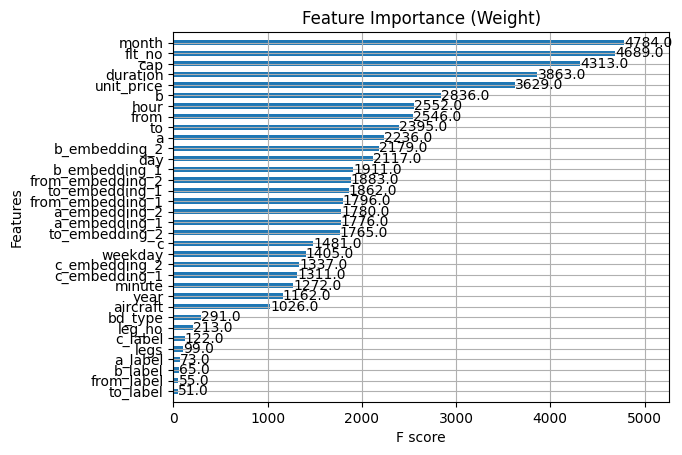

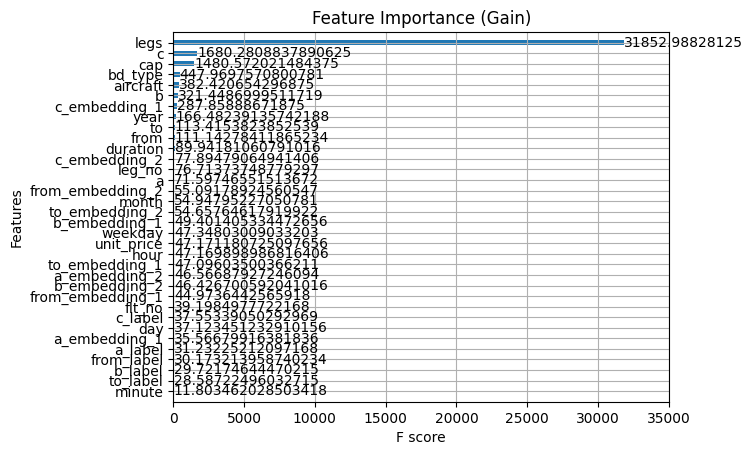

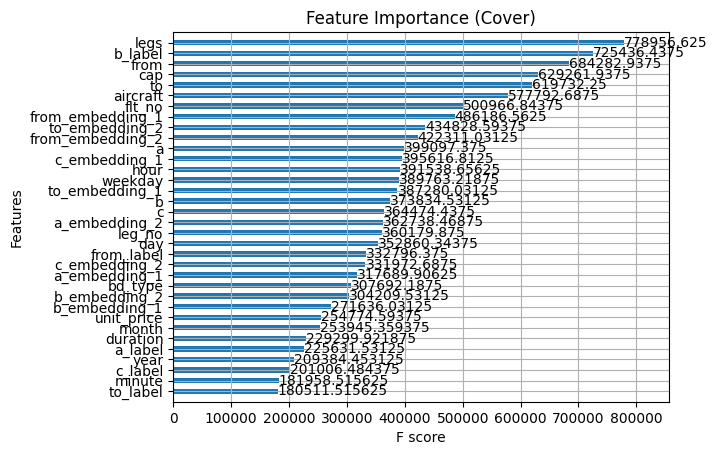

In [23]:
import xgboost as xgb
import matplotlib.pyplot as plt

# 假设 model 是训练好的 XGBoost 模型
xgb.plot_importance(model, importance_type='weight', title="Feature Importance (Weight)", height=0.5)
plt.show()

xgb.plot_importance(model, importance_type='gain', title="Feature Importance (Gain)", height=0.5)
plt.show()

xgb.plot_importance(model, importance_type='cover', title="Feature Importance (Cover)", height=0.5)
plt.show()